# ZSOM — Self-Organizing Map Demo Notebook

This notebook demonstrates the **ZSOM** library — a pure NumPy implementation of
Self-Organizing Maps with optional Numba acceleration.

A SOM is an unsupervised competitive neural network that projects high-dimensional
input data onto a low-dimensional (2D) discrete grid while preserving the
topological structure of the input space.

In [10]:
%matplotlib inline
import sys
import os

# Add project root to sys.path so 'examples' package is resolvable
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), "..")))

import numpy as np
import matplotlib.pyplot as plt

from zsom import SOM, HAS_NUMBA, __version__
from zsom.metrics import dist_manhattan

from examples.datasets import make_clusters, make_rings, make_swiss, make_grid, make_obj
from examples.visualization import plot_static

print(f"ZSOM v{__version__}")
status = "✅ enabled" if HAS_NUMBA else "❌ not installed"
print(f"Numba acceleration: {status}")

ZSOM v1.0.0
Numba acceleration: ✅ enabled


## 1 · Gaussian Clusters (2D)

Three isotropic blobs — the simplest test case. The SOM should tile into
three clean regions.

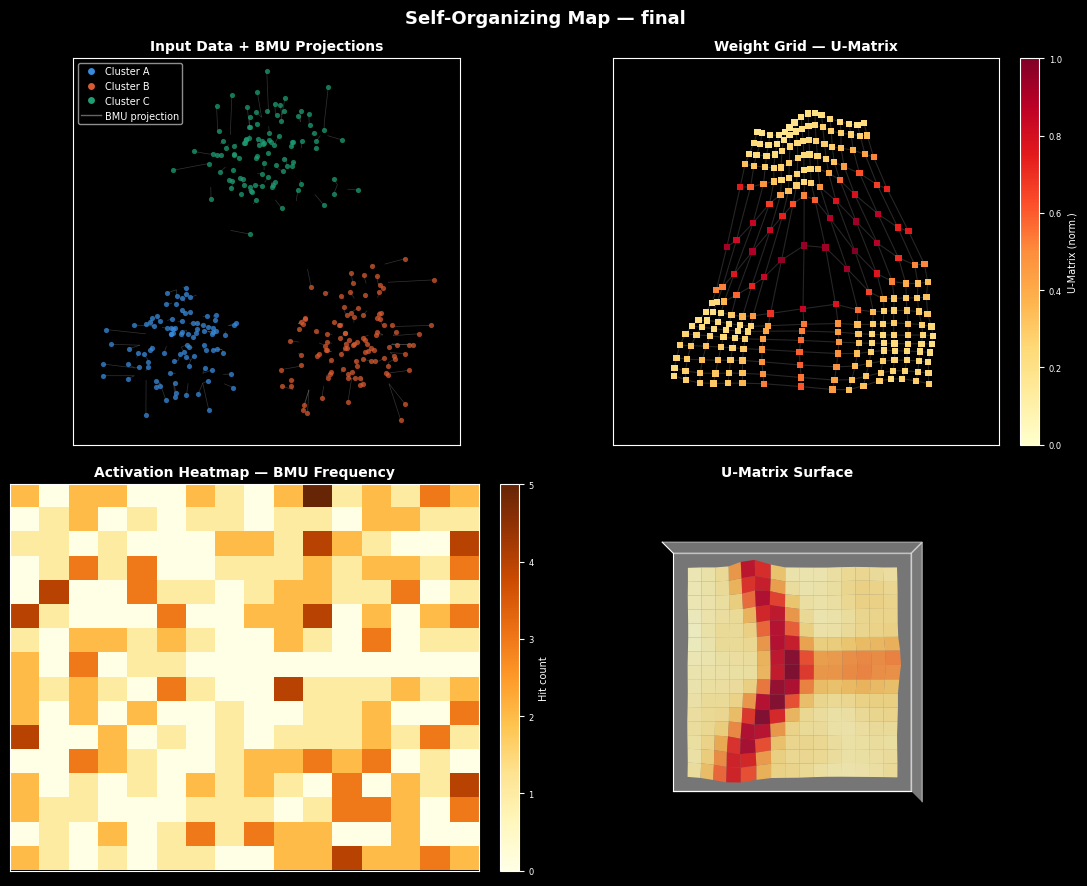

In [22]:
rng = np.random.default_rng(42)
pts, labels = make_clusters(300, rng)

som = SOM(16, 16, 2, rng, init="pca", data=pts, metric=dist_manhattan)
som.fit(pts, epochs=256, learning_rate=0.6, adaptive_lr=True)

plot_static(som, pts, labels, dataset_name="clusters", view_3d_from_top=True)

## 2 · Concentric Rings (2D) — Cosine distance

Non-convex topology — the SOM must wrap its grid around two concentric rings.
We use **cosine distance** here, which is angle-based and scale-invariant.
Cosine distance works well for non-convex structures because it separates
points by angular direction from the origin rather than absolute position.

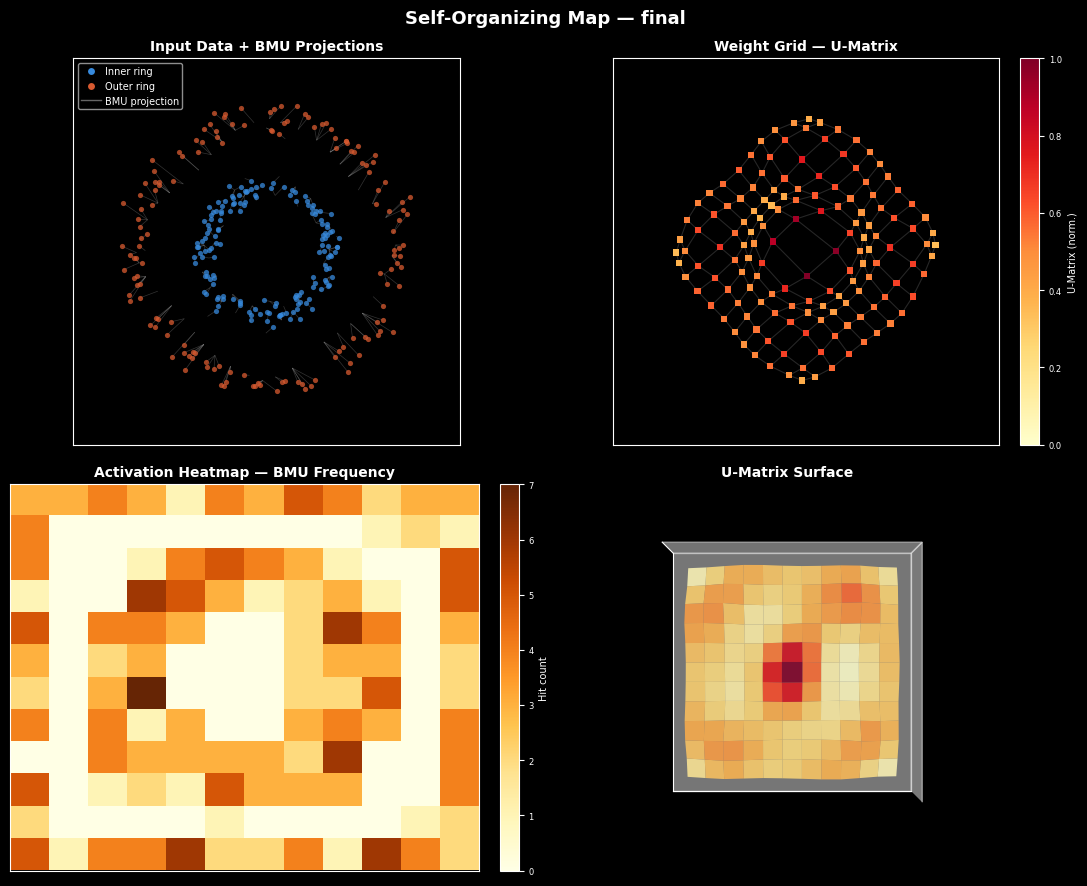

In [12]:
from zsom import dist_chebyshev

rng = np.random.default_rng(42)
pts, labels = make_rings(300, rng)

som = SOM(12, 12, 2, rng, metric=dist_chebyshev)
snapshots = som.fit(pts, epochs=80, learning_rate=0.5)

plot_static(som, pts, labels, dataset_name="ring", view_3d_from_top=True)

## 3 · Swiss Roll (2D) — Manhattan distance

Curvilinear manifold — the SOM unrolls the spiral. We use **Manhattan (L1)
distance**, which is more robust to outliers than Euclidean because
large deviations in a single dimension are not squared. Good for
curvilinear manifolds where the data varies strongly along specific axes.

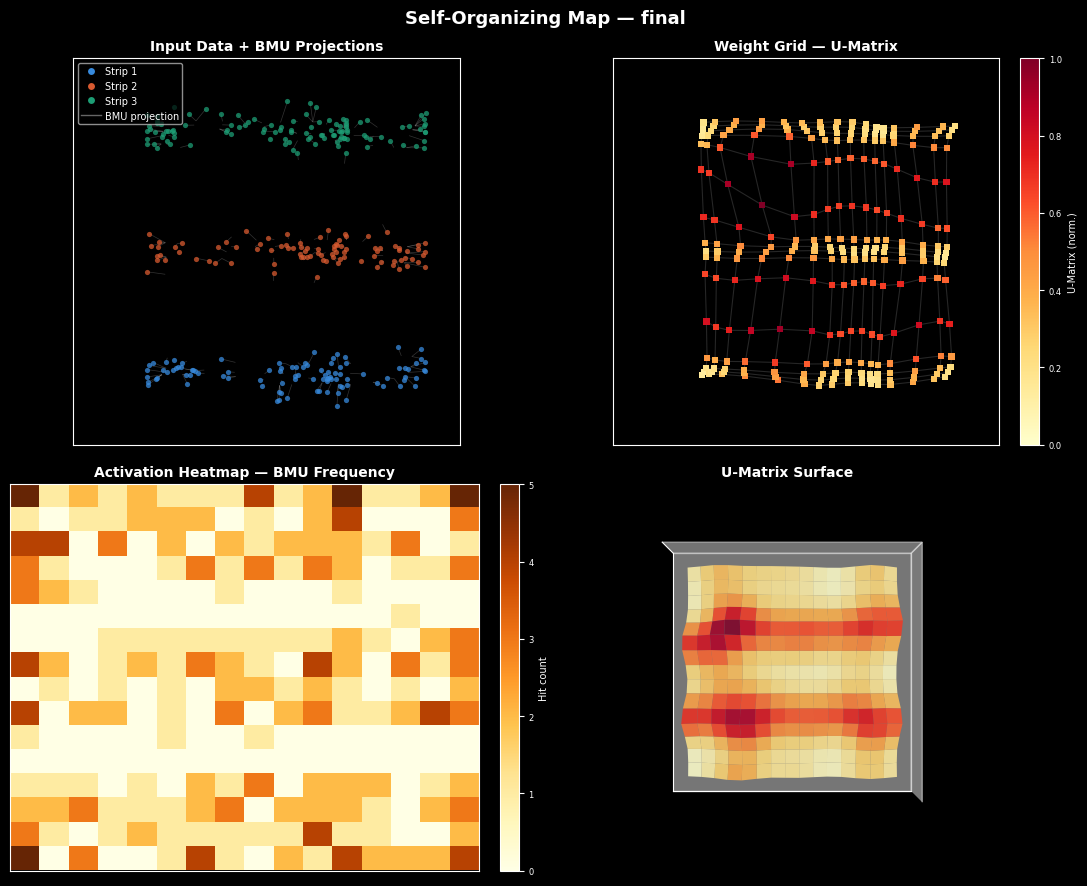

In [13]:
rng = np.random.default_rng(42)
pts, labels = make_swiss(300, rng)

som = SOM(16, 16, 2, rng, metric=dist_manhattan)
snapshots = som.fit(pts, epochs=256, learning_rate=0.6)

plot_static(som, pts, labels, dataset_name="swiss", view_3d_from_top=True)

## 4 · Jittered Grid (2D)

Sanity check — a well-trained SOM should tile a uniform grid evenly.

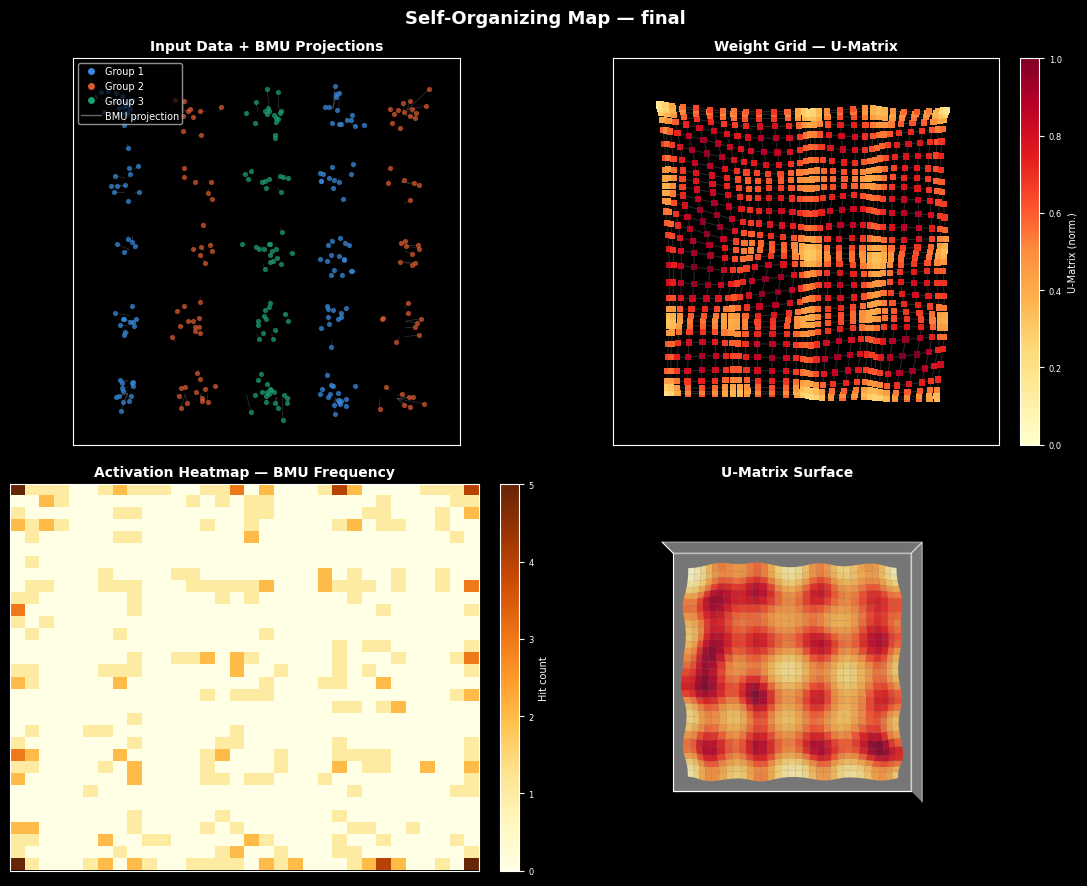

In [14]:
rng = np.random.default_rng(42)
pts, labels = make_grid(300, rng)

som = SOM(32, 32, 2, rng, metric=dist_manhattan)
snapshots = som.fit(pts, epochs=256, learning_rate=0.6)

plot_static(som, pts, labels, dataset_name="grid", view_3d_from_top=True)

## 5 · 3D Bunny

Procedural Stanford-bunny-like point cloud. The 2D SOM mesh drapes over
the 3D surface, demonstrating topology-preserving dimensionality reduction.

The 3D panel shows the original data + the SOM mesh together.

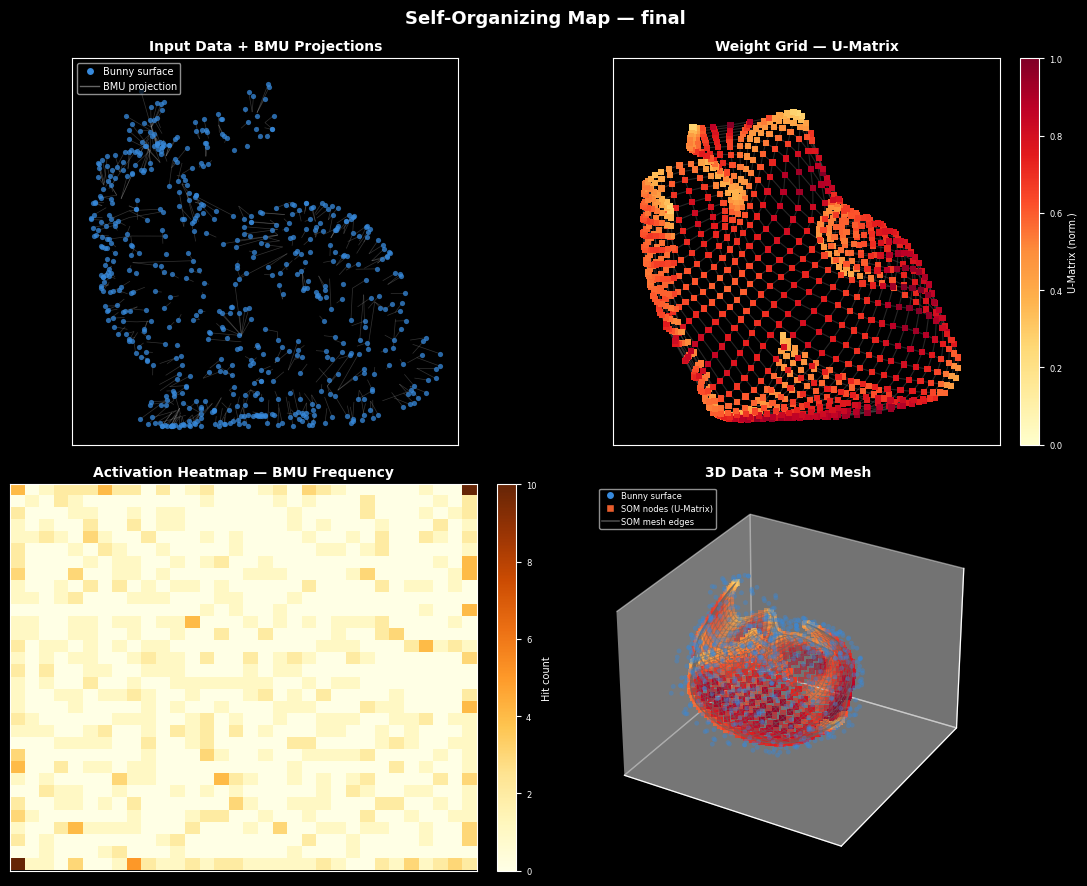

In [15]:
rng = np.random.default_rng(42)
pts, labels = make_obj(600, rng, obj="bunny")

som = SOM(32, 32, 3, rng, init="pca", data=pts)
snapshots = som.fit(pts, epochs=1024, learning_rate=0.6)

plot_static(som, pts, labels, dataset_name="bunny")

## 6 · Hexagonal Topology

Hex grid with 6-connected neighborhood — less quantisation error on
isotropic data.

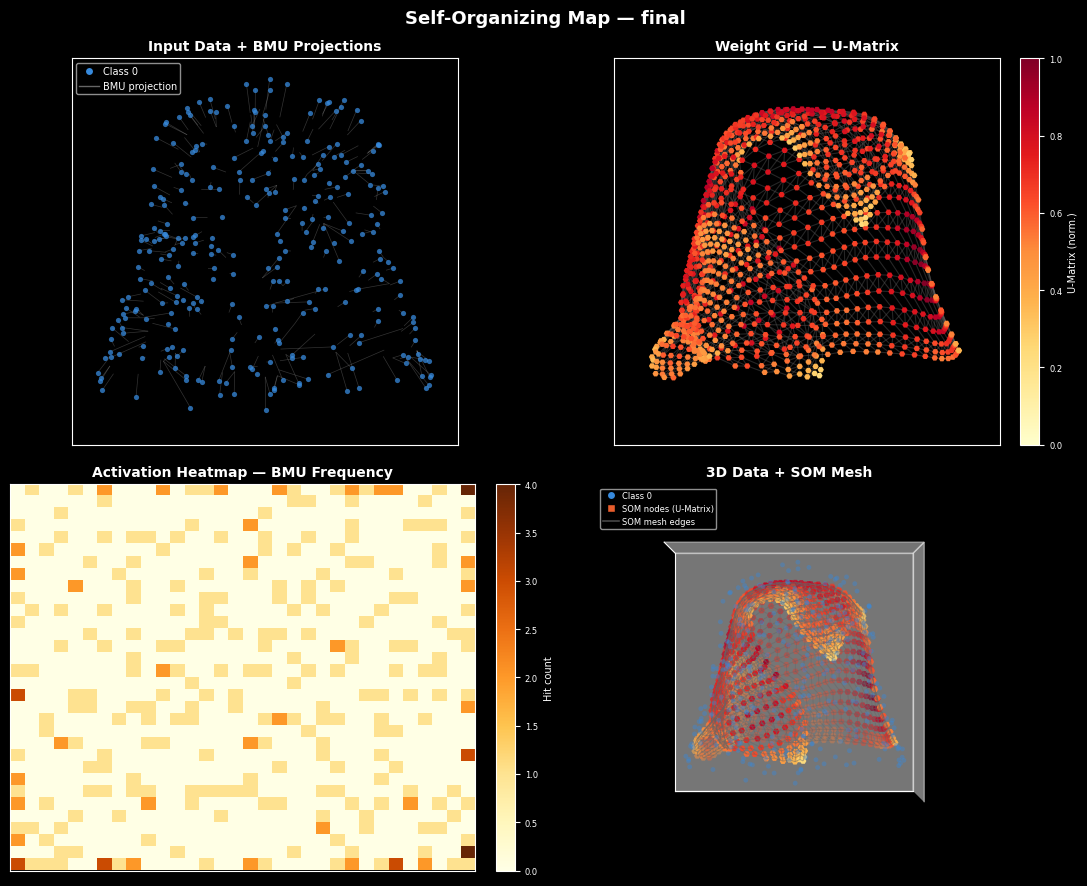

In [ ]:
rng = np.random.default_rng(42)
pts, labels = make_obj(300, rng, obj="vader")

som = SOM(32, 32, 3, rng, topology="hex")
som.fit(pts, epochs=1000, learning_rate=0.6, adaptive_lr=True)
plot_static(som, pts, labels, dataset_name="vader", view_3d_from_top=True)

## 7 · Distance Metrics

Compare Euclidean vs Manhattan vs Cosine distance on the Swiss roll.

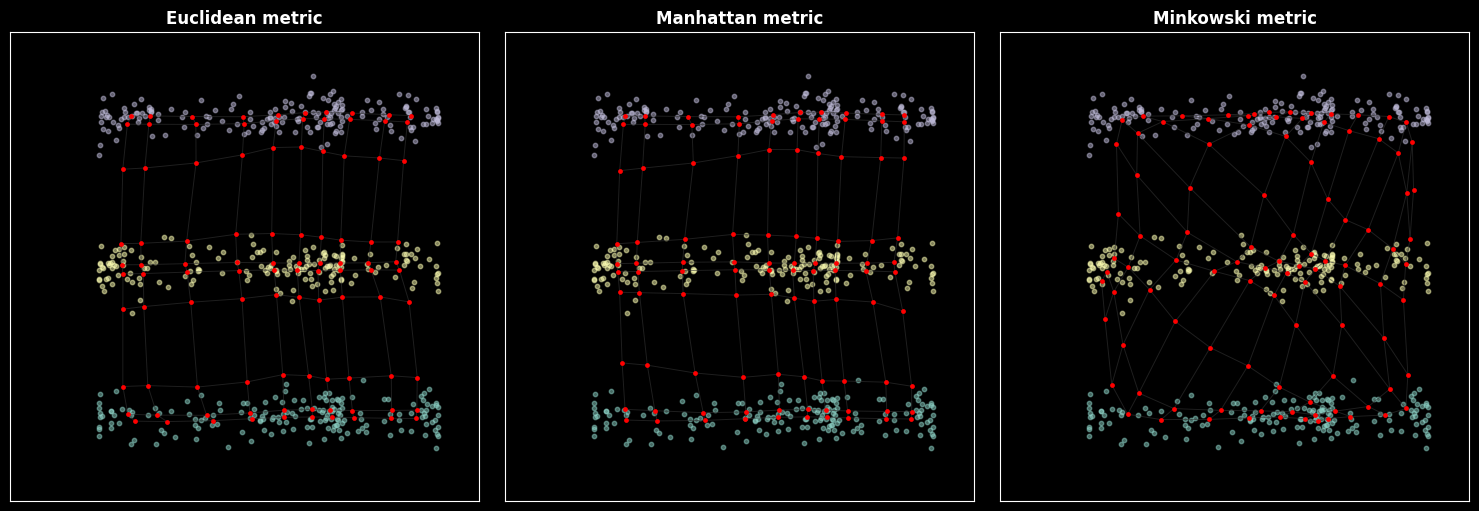

In [ ]:
from zsom import dist_euclidean, dist_manhattan, dist_minkowski
from matplotlib.collections import LineCollection
from examples.visualization import _build_grid_segments_2d

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, metric_fn) in zip(
    axes,
    [
        ("Euclidean", dist_euclidean),
        ("Manhattan", dist_manhattan),
        ("Minkowski", dist_minkowski),
    ],
):
    rng = np.random.default_rng(42)
    pts, labels = make_swiss(512, rng)
    som = SOM(10, 10, 2, rng, metric=metric_fn)
    som.fit(pts, epochs=128, learning_rate=0.5)

    ax.set_title(f"{name} metric", fontweight="bold")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for lbl in np.unique(labels):
        m = labels == lbl
        ax.scatter(pts[m, 0], pts[m, 1], s=10, alpha=0.5)

    segs = _build_grid_segments_2d(som)

    if len(segs):
        ax.add_collection(LineCollection(segs, colors="#333", lw=0.7, alpha=0.6))

    ax.scatter(
        som.weights[:, :, 0].ravel(),
        som.weights[:, :, 1].ravel(),
        c="red",
        s=12,
        zorder=5,
        linewidths=0,
    )

plt.tight_layout()
plt.show()

## 8 · Numba Acceleration

If `numba` is installed (`pip install zsom[numba]`), the heavy distance
computation and batch update are JIT-compiled and parallelised.

Check the status and optionally benchmark:

In [18]:
print(f"Numba available: {HAS_NUMBA}")

if HAS_NUMBA:
    import time

    rng = np.random.default_rng(42)
    pts, _ = make_clusters(1000, rng)

    # With Numba
    som_nb = SOM(16, 16, 2, np.random.default_rng(42), use_numba=True)
    t0 = time.perf_counter()
    som_nb.fit(pts, epochs=50, learning_rate=0.5)
    t_numba = time.perf_counter() - t0

    # Without Numba
    som_np = SOM(16, 16, 2, np.random.default_rng(42), use_numba=False)
    t0 = time.perf_counter()
    som_np.fit(pts, epochs=50, learning_rate=0.5)
    t_numpy = time.perf_counter() - t0

    print(f"NumPy:  {t_numpy:.2f}s")
    print(f"Numba:  {t_numba:.2f}s")
    print(f"Speedup: {t_numpy / t_numba:.1f}×")
else:
    print("Install numba for acceleration: pip install zsom[numba]")

Numba available: True
NumPy:  0.88s
Numba:  0.86s
Speedup: 1.0×
